In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
#Load data
df = pd.read_csv(r"C:\Users\Administrator\Documents\Downloads\supermarket.csv.csv")

In [15]:
#identify data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [34]:
df.describe()
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [23]:
df.duplicated().sum()

np.int64(5268)

In [19]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [33]:
 print(df[['Quantity', 'Price']].describe())

            Quantity          Price
count  401605.000000  401605.000000
mean       12.183245       3.474100
std       250.282726      69.763952
min    -80995.000000       0.000000
25%         2.000000       1.250000
50%         5.000000       1.950000
75%        12.000000       3.750000
max     80995.000000   38970.000000


In [35]:
##Data quality errors
print(f"1. Missing Descriptions   : {df['Description'].isnull().sum():,} rows")

1. Missing Descriptions   : 0 rows


In [36]:
print(f"2. Missing Customer IDs   : {df['Customer ID'].isnull().sum():,} rows ({df['Customer ID'].isnull().mean()*100:.1f}%)")

2. Missing Customer IDs   : 0 rows (0.0%)


In [37]:
print(f"3. Negative Quantities    : {(df['Quantity'] < 0).sum():,} rows (returns/cancellations)")
print(f"4. Negative Prices        : {(df['Price'] < 0).sum():,} rows (credit adjustments)")
print(f"5. Zero Price Records     : {(df['Price'] == 0).sum():,} rows")

3. Negative Quantities    : 8,872 rows (returns/cancellations)
4. Negative Prices        : 0 rows (credit adjustments)
5. Zero Price Records     : 40 rows


In [38]:
#Cleaning data
df_clean = df.copy()

In [41]:
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]

In [40]:
df_clean = df_clean.dropna(subset=['Description'])

In [42]:
df_clean['Description'] = df_clean['Description'].str.strip().str.title()

In [45]:
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['Price']

In [47]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)

In [49]:
df_clean['DayOfWeek']  = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour']       = df_clean['InvoiceDate'].dt.hour
df_clean['Year']       = df_clean['InvoiceDate'].dt.year

In [50]:
print(f"   Removed: {len(df) - len(df_clean):,} problematic records")

   Removed: 8,912 problematic records


In [51]:
#BUSSINESS METRICS
total_revenue   = df_clean['TotalSales'].sum()
total_orders    = df_clean['Invoice'].nunique()
total_customers = df_clean['Customer ID'].nunique()
total_products  = df_clean['Description'].nunique()
avg_order_value = df_clean.groupby('Invoice')['TotalSales'].sum().mean()

In [52]:
print("\n=== KEY BUSINESS METRICS ===")
print(f"💰 Total Revenue      : £{total_revenue:,.2f}")
print(f"🧾 Total Orders       : {total_orders:,}")
print(f"👥 Total Customers    : {total_customers:,}")
print(f"📦 Unique Products    : {total_products:,}")
print(f"🛒 Avg Order Value    : £{avg_order_value:,.2f}")
 


=== KEY BUSINESS METRICS ===
💰 Total Revenue      : £8,887,226.89
🧾 Total Orders       : 18,532
👥 Total Customers    : 4,338
📦 Unique Products    : 3,866
🛒 Avg Order Value    : £479.56


In [53]:
#=====Aggregations=====
#Monthly Revnue
monthly_revenue = df_clean.groupby('Month')['TotalSales'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Revenue']

In [54]:
 #Top 10 Products by Quantity
top_qty = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index()
 

In [55]:
# Top 10 Products by Revenue
top_rev = df_clean.groupby('Description')['TotalSales'].sum().sort_values(ascending=False).head(10).reset_index()

In [56]:
# Country Revenue
country_rev = df_clean.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).reset_index()

In [57]:
# Day of Week Sales
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales = df_clean.groupby('DayOfWeek')['TotalSales'].sum().reindex(dow_order).reset_index()

In [58]:
print("\n-Top 5 Products by Revenue- ")
print(top_rev.head())


-Top 5 Products by Revenue- 
                          Description  TotalSales
0         Paper Craft , Little Birdie   168469.60
1            Regency Cakestand 3 Tier   142264.75
2  White Hanging Heart T-Light Holder   100392.10
3             Jumbo Bag Red Retrospot    85040.54
4      Medium Ceramic Top Storage Jar    81416.73


In [59]:
#----VISUALIZATION----
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})
COLORS = ['#2563EB','#16A34A','#DC2626','#D97706','#7C3AED',
          '#0891B2','#DB2777','#65A30D','#EA580C','#475569']
BG = '#F8FAFC'

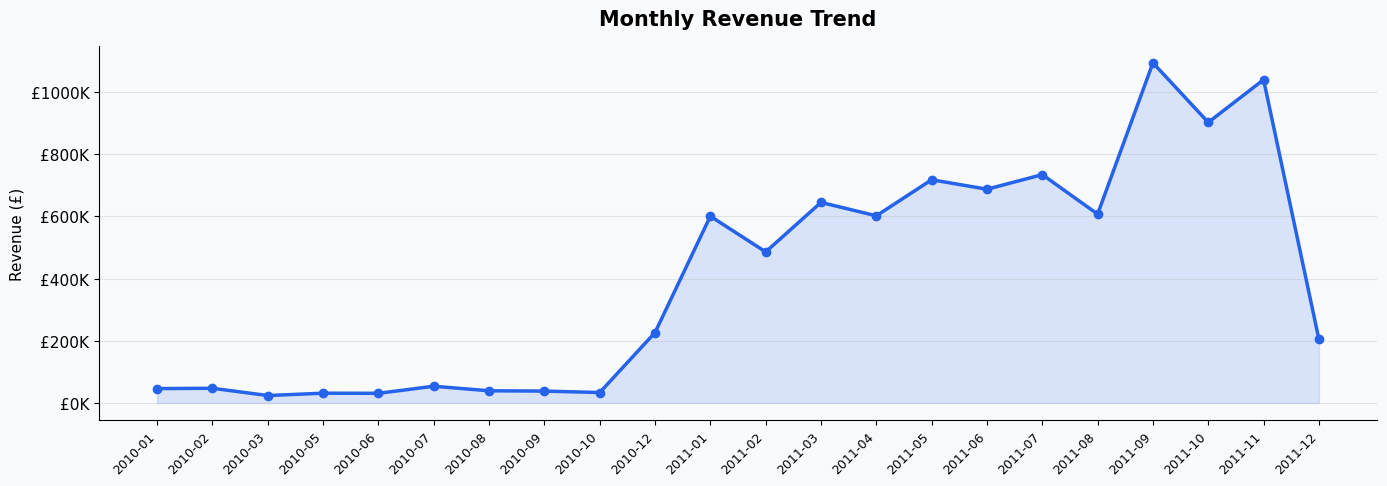

 Chart 1: Monthly Revenue


In [61]:
# ---- Monthly Revenue Trend ----
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.fill_between(range(len(monthly_revenue)), monthly_revenue['Revenue'], alpha=0.15, color=COLORS[0])
ax.plot(range(len(monthly_revenue)), monthly_revenue['Revenue'],
        color=COLORS[0], linewidth=2.5, marker='o', markersize=6)
ax.set_xticks(range(len(monthly_revenue)))
ax.set_xticklabels(monthly_revenue['Month'], rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Revenue Trend', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(" Chart 1: Monthly Revenue")

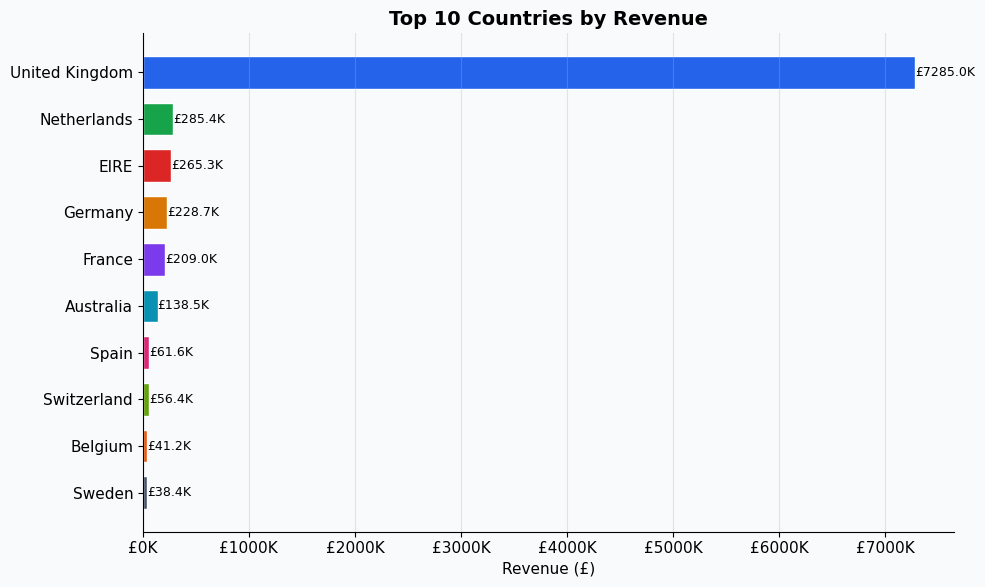

Chart 2 : Country Revenue


In [62]:
# ---- Top 10 Countries by Revenue ----
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)
top10_c = country_rev.head(10)
bars = ax.barh(top10_c['Country'][::-1], top10_c['TotalSales'][::-1],
               color=COLORS[:10][::-1], edgecolor='white', height=0.7)
ax.set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
for bar, val in zip(bars, top10_c['TotalSales'][::-1]):
    ax.text(val+1000, bar.get_y()+bar.get_height()/2,
            f'£{val/1000:.1f}K', va='center', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_country_revenue.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 2 : Country Revenue")

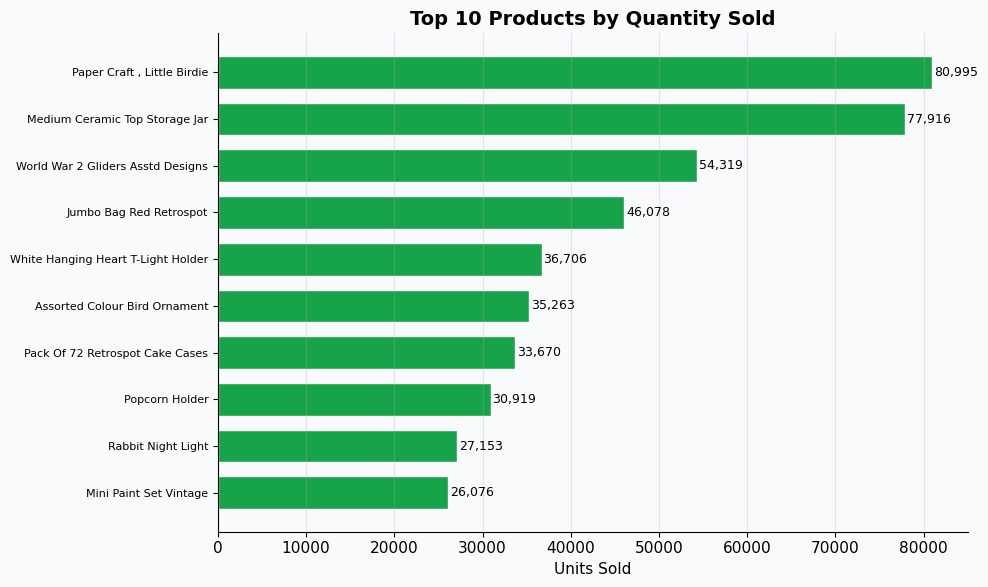

Chart 3 : Top Products by Qty


In [65]:
# ---- Top 10 Products by Quantity ----
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(top_qty['Description'][::-1], top_qty['Quantity'][::-1],
               color=COLORS[1], edgecolor='white', height=0.7)
ax.set_title('Top 10 Products by Quantity Sold', fontsize=14, fontweight='bold')
ax.set_xlabel('Units Sold')
for bar, val in zip(bars, top_qty['Quantity'][::-1]):
    ax.text(val+200, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='y', labelsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('chart3_top_products_qty.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 3 : Top Products by Qty")

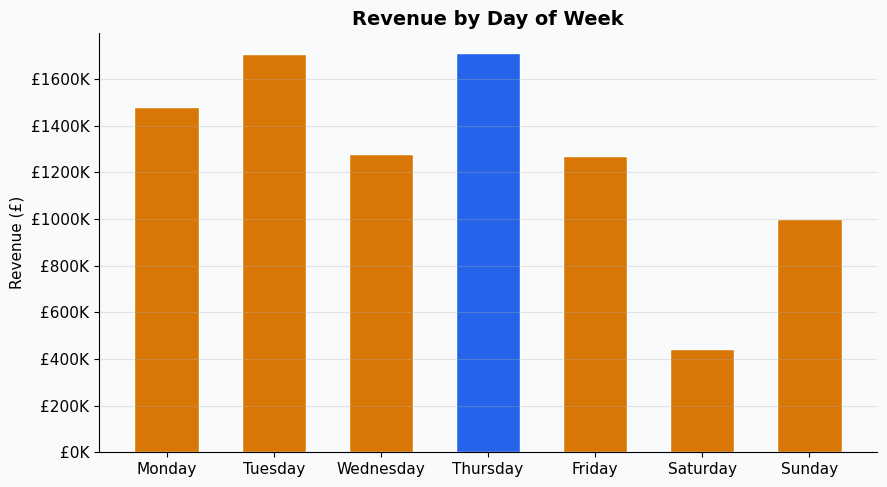

Chart 4: Day of Week Revenue


In [70]:
# ----Sales by Day of Week ----
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)
bar_colors = [COLORS[0] if i == dow_sales['TotalSales'].idxmax() else COLORS[3]
              for i in range(len(dow_sales))]
ax.bar(dow_sales['DayOfWeek'], dow_sales['TotalSales'],
       color=bar_colors, edgecolor='white', width=0.6)
ax.set_title('Revenue by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart4_day_of_week.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 4: Day of Week Revenue")

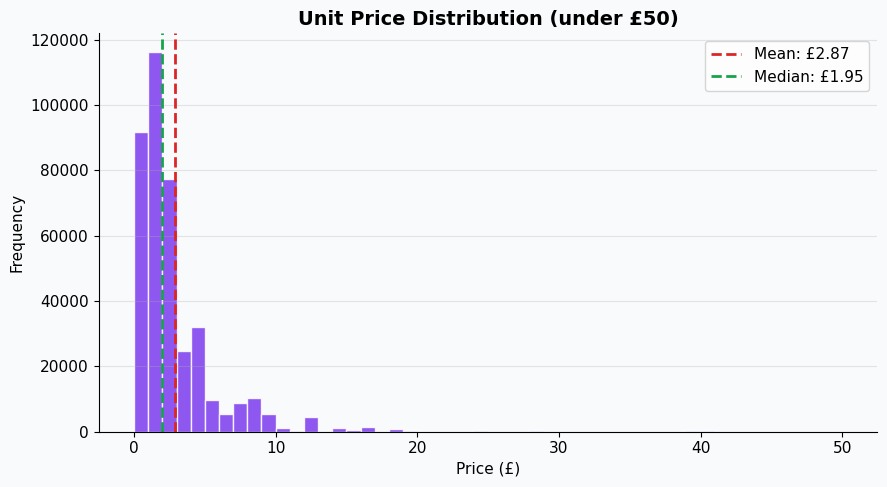

 Chart 5 : Price Distribution


In [71]:
# ---- Price Distribution ----
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)
price_data = df_clean[df_clean['Price'] < 50]['Price']
ax.hist(price_data, bins=50, color=COLORS[4], edgecolor='white', alpha=0.85)
ax.axvline(price_data.mean(), color=COLORS[2], linestyle='--', linewidth=2,
           label=f'Mean: £{price_data.mean():.2f}')
ax.axvline(price_data.median(), color=COLORS[1], linestyle='--', linewidth=2,
           label=f'Median: £{price_data.median():.2f}')
ax.set_title('Unit Price Distribution (under £50)', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (£)')
ax.set_ylabel('Frequency')
ax.legend()
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart5_price_distribution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(" Chart 5 : Price Distribution")

In [72]:
# ───  Statistical Summary ─────────────────────────────
print("\n=== BASIC STATISTICS ===")
print(f"Revenue — Mean   : £{df_clean['TotalSales'].mean():,.2f}")
print(f"Revenue — Median : £{df_clean['TotalSales'].median():,.2f}")
print(f"Revenue — Std Dev: £{df_clean['TotalSales'].std():,.2f}")
print(f"Price   — Mean   : £{df_clean['Price'].mean():,.2f}")
print(f"Price   — Median : £{df_clean['Price'].median():,.2f}")
print(f"Qty     — Mean   : {df_clean['Quantity'].mean():.1f} units")
print(f"Qty     — Median : {df_clean['Quantity'].median():.0f} units")
 
best_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax()]
worst_month = monthly_revenue.loc[monthly_revenue['Revenue'].idxmin()]
print(f"\n🏆 Best Month  : {best_month['Month']}  — £{best_month['Revenue']:,.0f}")
print(f"📉 Worst Month : {worst_month['Month']} — £{worst_month['Revenue']:,.0f}")


=== BASIC STATISTICS ===
Revenue — Mean   : £22.63
Revenue — Median : £12.45
Revenue — Std Dev: £311.10
Price   — Mean   : £3.13
Price   — Median : £1.95
Qty     — Mean   : 13.1 units
Qty     — Median : 6 units

🏆 Best Month  : 2011-09  — £1,093,338
📉 Worst Month : 2010-03 — £23,877


In [73]:
# ───  Save Cleaned Dataset for Power BI ──────────────
df_clean.to_csv('supermarket_cleaned.csv', index=False)
print("\n Cleaned dataset saved as 'supermarket_cleaned.csv'")
print(f"   Ready for Power BI import: {len(df_clean):,} rows")
 


 Cleaned dataset saved as 'supermarket_cleaned.csv'
   Ready for Power BI import: 392,693 rows
